Arbol
Joselyn Herrera


## Parte 1: Arbol de decision (Decision tree)

In [2]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [3]:
mydata = load_iris()

x= mydata.data
y= mydata.target #ETIQUETAS

print (x.shape)
print (y.shape)

(150, 4)
(150,)


In [4]:
mydata.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
mydata.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [7]:
X_tv, X_test, y_tv, y_test = train_test_split(x, y, test_size=.2, shuffle=True, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=.25, shuffle=True, random_state=1)
print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de validación:', X_val.shape)
print('Tamaño del conjunto de prueba', X_test.shape)


Tamaño del conjunto de entrenamiento: (90, 4)
Tamaño del conjunto de validación: (30, 4)
Tamaño del conjunto de prueba (30, 4)


{'whiskers': [<matplotlib.lines.Line2D at 0x1d0a44fd8b0>,
 'caps': [<matplotlib.lines.Line2D at 0x1d0a44fc650>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d0a44fce60>,
 'medians': [<matplotlib.lines.Line2D at 0x1d0a44fe4b0>,
 'fliers': [<matplotlib.lines.Line2D at 0x1d0a44fd820>,
 'means': []}

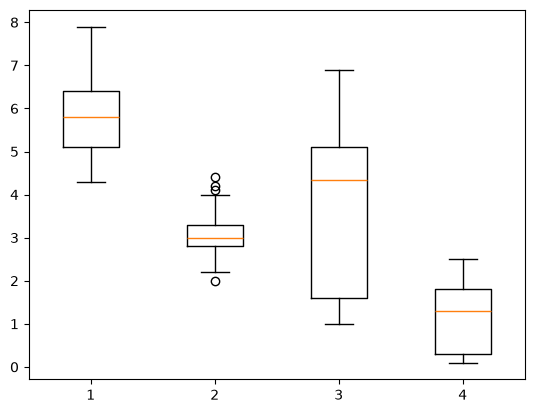

In [9]:
plt.boxplot(x,label=mydata.feature_names)

In [11]:
## Entrenamiento de Evaluacion y prueba 

modeloDT = DecisionTreeClassifier()   # Incializamos el modelo con los hiperparámetros predeterminados.

clf = modeloDT.fit(X_train, y_train)   # Entrenamos con el conjunto de entrenamiento para obtener nuestro primer clasificador (clf)

# Podemos observar el desempeño en el conjunto de entrenamieto para verificar

# el subentrenamiento o sobreentrenamiento, pero no para evaluar el modelo en sí:

print('Exactitud en el conjunto de entrenamiento: %.2f' % clf.score(X_train, y_train))

# Así, el conjunto con el que nos interesa evaluar el desempeño es con los de validación,

# así que calculamos primero sus predicciones y después las usamos para evaluar el modelo:

predi = clf.predict(X_val)     # Obtenemos predicciones de 0s, 1s o 2s para cada clase

print('Exactitud en el conjunto de validación: %.2f' % clf.score(X_val, y_val))

Exactitud en el conjunto de entrenamiento: 1.00
Exactitud en el conjunto de validación: 0.97


In [12]:
print(confusion_matrix(y_val, predi)) # Matriz de confusion para el conjunto de validacion 

[[ 9  0  0]
 [ 0 10  0]
 [ 0  1 10]]


In [14]:
print(confusion_matrix(y_val, predi) /y_val.shape[0])

[[0.3        0.         0.        ]
 [0.         0.33333333 0.        ]
 [0.         0.03333333 0.33333333]]


In [16]:
clf.score(X_val, y_val)

0.9666666666666667

In [18]:
!pip install pydotplus

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24659 sha256=c8fbd435f7cbff742fc9b9c2bfd8be3faa1de8582f318aeb9de5f8399f1b661f
  Stored in directory: c:\users\usuario\appdata\local\pip\cache\wheels\77\54\7c\c8077b6151c819495492300386cf9b151a954259d1a658c63b
Successfully built pydotplus



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
## Graficar el árbol de decisión
from sklearn import tree
import pydotplus
from IPython.display import Image

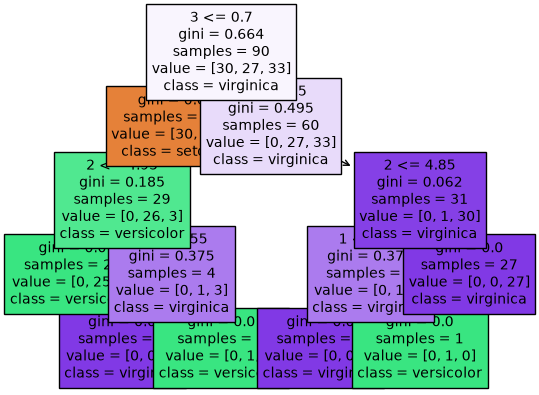

In [21]:
# 1. Configurar el tamaño de la imagen plt.figure(figsize=(15, 10)) 
# 2. Dibujar el árbol directamente 
tree.plot_tree(decision_tree=clf, 
                max_depth=None, 
                feature_names=list(pd.DataFrame(X_train).columns.astype(str)),
                class_names=[str(c) for c in mydata.target_names], 
                filled=True, 
                proportion=False, 
                fontsize=10) 
# 3. Mostrar la imagen en Jupyter 
plt.show()

## Parte 2. Random Forest(Bosque Aleatorio)

In [28]:
import sklearn.datasets
# o también:
from sklearn import datasets

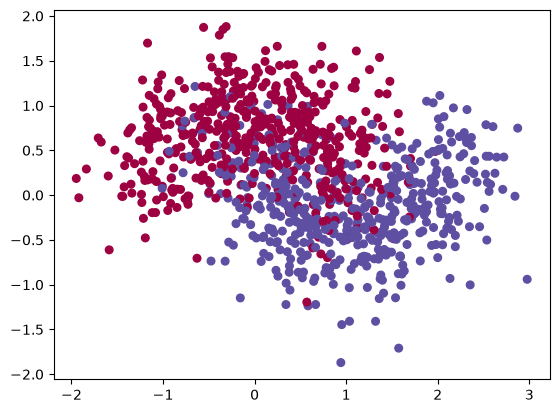

In [29]:
N=1000  # total de datos a generar en la muestra.

noisy_data = sklearn.datasets.make_moons(n_samples=N, noise=0.4, random_state=17)

X, Y = noisy_data

 

plt.scatter(X[:,0], X[:,1], c=Y, s=30, cmap=plt.cm.Spectral);

In [33]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=.4, shuffle=True, random_state=17)

mimodelo = RandomForestClassifier()

clf = mimodelo.fit(Xtrain, Ytrain)

results = clf.predict(Xtest)

confusion_matrix(Ytest, results)

array([[165,  37],
       [ 31, 167]])

In [34]:
clf.score(Xtest,Ytest)  # es la Exactitud (accuracy)

0.83

In [35]:
clf.feature_importances_

array([0.45867962, 0.54132038])

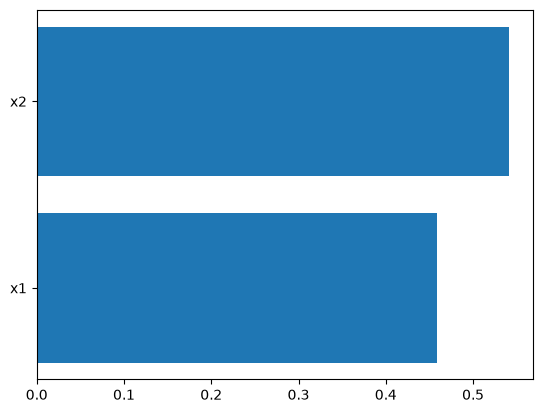

In [38]:
plt.barh(['x1', 'x2'], width=clf.feature_importances_);

In [41]:
## Algunos de lo hiperparámetros del clasificador bosque aleatorio:
mimodelo2 = RandomForestClassifier(n_estimators=10,  # número de árboles en el Forest y después promedia por votación.
                                   criterion='gini',   # métrica para determinar las ramas. También puede ser: 'entropy', para la GananciaDeInformación (IG).
                                   max_depth=2, # Depth=k : máximo 2^k líneas/ramas.        
                                   min_samples_split = 6,  # mínimo de puntos muestrales requeridos en un nodo para hacer la ramificación. Puede ser fracción de 0 a 1.
                                   min_samples_leaf = 4,  # mínimo de puntos muestrales que deben quedar en cada nueva ramificación (hojas). Puede ser fracción de 0 a 1.
                                   max_features= 'sqrt',   # número de características (features) que se consideran en cada ramificación: auto=sqrt(n_features).
                                   max_leaf_nodes=16,  # solo nos quedamos con las mejores k hojas.
                                   bootstrap=True,  # Cada Árbol se muestrea seleccionando la cantidad de datos del conjunto de entrenamiento, pero con reemplazo. False:los datos usados en cada árbol simpre es el mismo, el Train-set.
                                   oob_score=True,  # en caso de utilizar Out-of-bag samples.
                                   verbose=0,     # tipo de despliega de información durante el entrenamiento.
                                   n_jobs=-1,    # total de hilos a usar en las rutinas paralelizables: "-1" :usar todos los posibles. 
                                   max_samples=None,   # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0]. 
                                   random_state=19)

In [42]:
clf2 = mimodelo2.fit(Xtrain,Ytrain)
clf2.score (Xtest, Ytest)

C:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


0.855